[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lweber89/pygeog510/blob/main/labs/geog510_lab05_lweber89.ipynb)

## Exercise 1

In [39]:
#Import modules and functions

import random
from math import radians, sin, cos, sqrt, atan2

In [40]:
# Function to calculate the great-circle distance between two points
# on a sphere using the Haversine formula
def calculate_distance (lat1, lon1, lat2, lon2):

    R = 6371.0  # Earth radius in kilometers

    # Convert degrees to radians for the math functions
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    # Haversine formula core logic
    a = (
        sin(dlat / 2) ** 2
        + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    )
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    #Calculate and return distance
    distance = R * c

    return distance

In [41]:
#List of coordinates of 10 US National Parks

locations = [
    (44.3386, -68.2733, "Acadia NP"),
    (36.1070, -112.1130, "Grand Canyon NP"),
    (44.4280, -110.5885, "Yellowstone NP"),
    (37.8651, -119.5383, "Yosemite NP"),
    (48.7596, -113.7870, "Glacier NP"),
    (25.2866, -80.5749, "Everglades NP"),
    (43.8550, -102.3400, "Badlands NP"),
    (35.6131, -83.4811, "Great Smoky Mountains NP"),
    (37.3000, -113.0000, "Zion NP"),
    (63.1148, -151.1926, "Denali NP")
]

In [42]:
#Exercise 1 function execution / testing
counter = 0

while counter < 10:
    p1, p2 = random.sample(locations, 2)  #Select 2 random points (p1 and p2) from National Parks

    #Call to calculate_distance function

    distance = calculate_distance(p1[0], p1[1], p2[0], p2[1])

    #Output of distance between the 2 randomly selected National Parks

    print(f"The distance between {p1[2]} and {p2[2]} is {distance:.2f} kilometers.")

    counter +=1

print("-" * 30)
print("Distance calculations complete. Have a great trip!")

The distance between Yellowstone NP and Grand Canyon NP is 934.20 kilometers.
The distance between Glacier NP and Denali NP is 2762.24 kilometers.
The distance between Denali NP and Badlands NP is 3740.86 kilometers.
The distance between Zion NP and Glacier NP is 1275.83 kilometers.
The distance between Great Smoky Mountains NP and Acadia NP is 1614.44 kilometers.
The distance between Glacier NP and Yellowstone NP is 539.99 kilometers.
The distance between Everglades NP and Glacier NP is 3883.71 kilometers.
The distance between Denali NP and Grand Canyon NP is 4000.96 kilometers.
The distance between Everglades NP and Badlands NP is 2852.02 kilometers.
The distance between Zion NP and Yosemite NP is 579.44 kilometers.
------------------------------
Distance calculations complete. Have a great trip!


## Exercise 2

In [43]:
# Function to batch calculate distances between list of points

def batch_distance_calculation (geocoord_list):

    """
    Iterates through a list of coordinates and calculates the
    Haversine distance between each consecutive pair.
    """

    distances = []

   # Use range(len - 1) to ensure stopping at the second-to-last item,
   # preventing an 'Index Out of Bounds' error when looking ahead.

        # Unpack the current point and the next point in the sequence
    for i in range(len(geocoord_list) - 1):
            lat1, lon1, park_name1 = geocoord_list[i]
            lat2, lon2, park_name2 = geocoord_list[i + 1]

        #Calculate distance via a call to calculate_distance function
            distance = calculate_distance(lat1, lon1, lat2, lon2)
            distances.append(distance)

    #Return a list of distances between consecutive points

    return distances

In [44]:
#Exercise 2 function execution and testing

distances = batch_distance_calculation(locations)

counter = 0

#Loop through list of returned distances and output

while counter < len(distances):

    print(f"The distance between {locations [counter][2]} and {locations [counter + 1][2]} is {distances[counter]:.0f} kilometers.")

    counter += 1

print("-" * 30)
print("Distance calculations complete. Have a great trip!")

The distance between Acadia NP and Grand Canyon NP is 3785 kilometers.
The distance between Grand Canyon NP and Yellowstone NP is 934 kilometers.
The distance between Yellowstone NP and Yosemite NP is 1045 kilometers.
The distance between Yosemite NP and Glacier NP is 1297 kilometers.
The distance between Glacier NP and Everglades NP is 3884 kilometers.
The distance between Everglades NP and Badlands NP is 2852 kilometers.
The distance between Badlands NP and Great Smoky Mountains NP is 1849 kilometers.
The distance between Great Smoky Mountains NP and Zion NP is 2636 kilometers.
The distance between Zion NP and Denali NP is 3847 kilometers.
------------------------------
Distance calculations complete. Have a great trip!


## Exercise 3

In [45]:
#Define Point class

class Point:

    #Instantiate Point class with lat, lon and name (if provided)

    def __init__(self, lat, lon, name="None"):

        #Initialize variables based on input

        self.lat = float(lat)
        self.lon = float(lon)
        self.name = name

    #Method to calculate distance between 2 Point objects (2nd Point is passed as a parameter)

    def distance_to(self, point_x):

        #Unpack lat/lon from points and call calculate_distance

        return calculate_distance(self.lat, self.lon, point_x.lat, point_x.lon)

    #Method to format output of Point information

    def __str__(self):
        return f"{self.name or 'Point'} ({self.lat}, {self.lon})"




In [46]:

#Exercise 3 - execution and testing of creating Point objects and calling distance_to method

#Set home point and create list of Point objects

home_point = Point(38.6247, -90.1848, "St. Louis, MO")

#Create list to hold Point objects

list_of_Points = []

# Create Point objects from previous list of locations (tuples)
list_of_Points = [Point(lat, lon, name) for lat, lon, name in locations]

# Iterate:  call distance_to method and output results
for pt in list_of_Points:
    print(f"Distance from {home_point.name} to {pt.name}: {home_point.distance_to(pt):.2f} km")


Distance from St. Louis, MO to Acadia NP: 1925.69 km
Distance from St. Louis, MO to Grand Canyon NP: 1953.25 km
Distance from St. Louis, MO to Yellowstone NP: 1810.99 km
Distance from St. Louis, MO to Yosemite NP: 2553.86 km
Distance from St. Louis, MO to Glacier NP: 2193.50 km
Distance from St. Louis, MO to Everglades NP: 1735.81 km
Distance from St. Louis, MO to Badlands NP: 1169.24 km
Distance from St. Louis, MO to Great Smoky Mountains NP: 681.96 km
Distance from St. Louis, MO to Zion NP: 2000.42 km
Distance from St. Louis, MO to Denali NP: 4812.80 km


## Exercise 4

In [47]:
#Function that reads a file of plain txt list of coords

def read_coordinates(file_name):

    #Define variable to build list of tuples

    coords_as_tuples = []

    try:

        #Open file for reading

        with open(file_name, "r") as infile:

            #Strip each line of white space

            for line in infile:
                clean_line = line.strip()

                #If there is a blank line, continue.

                if clean_line == "":
                    continue

                #Split the line on the expected comma

                coords = clean_line.split(",")

                #Check for length, if it is 2, assume potentially good data, convert to float, and check for in-range lat/lon - append to tuple list if all checks are passed.

                if len(coords) == 2:
                    lat = float(coords[0])
                    lon = float(coords[1])

                    if lat > 90 or lat < -90:
                        print(f"Latitude out of range: {lat}. Data not appended to the list.")

                    elif lon > 180 or lon < -180:
                        print(f"Longitude out of range: {lon} Data not appended to the list.")

                    else:
                        print(f"The data is in range and is being appended to the list!")
                        coords_as_tuples.append((lat, lon))

                #if the length is anything but 2, assume bad data and skip the line without crashing
                else:
                    print(f"Skipping malformed line: {clean_line}.  Data not appended to the list")

    #Handle FileNotFoundError and return an empty list
    except FileNotFoundError:
        print(f"Error: The file '{file_name}' was not found.")
        return [] # Return an empty list

    #Return a list of tuples

    return coords_as_tuples

In [48]:
#Define function for writing list of coordinates to a file.  If file name is not passed, set a default name

def write_coordinates(locations, output_file="geocoord_list.txt"):

    #Exit early if passed list is empty

    if not locations:
        print("The list of geocoords is empty. No file has been written.")
        return False

    #File operations with data integrity check
    try:
        with open(output_file, "w") as outfile:
            for lat, lon, name in locations:

                # Check for valid coordinate ranges
                if not (-90 <= lat <= 90):
                    print(f"Skipping '{name}': Latitude {lat} is out of range.")
                    continue

                if not (-180 <= lon <= 180):
                    print(f"Skipping '{name}': Longitude {lon} is out of range.")
                    continue

                # If valid, write to the file
                outfile.write(f"{name}: Latitude: {lat}, Longitude: {lon}\n")

            print(f"Successfully finished writing coordinates to '{output_file}'.")
            return True

    except PermissionError:
        print(f"Error: Permission denied. Cannot write to '{output_file}'.")
        return False
    except IOError as e:
        print(f"Error: A disk or file error occurred: {e}")
        return False
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return False

In [49]:
#Exercise 4 - invoke write_coordinates function

#Set an empty list for testing
locations1 = []

#Invoke function with an empty list

write_coordinates (locations1)

#Invoke function with list and file name

write_coordinates (locations, "NP_coords.txt")

The list of geocoords is empty. No file has been written.
Successfully finished writing coordinates to 'NP_coords.txt'.


True

## Exercise 5

In [50]:
# Create a sample coordinates.txt file
sample_data = """35.6895,139.6917
34.0522,-118.2437
51.5074,-0.1278
-33.8688,151.2093
48.8566,2.3522"""

output_file = "coordinates.txt"

try:
    with open(output_file, "w") as file:
        file.write(sample_data)
    print(f"Sample file '{output_file}' has been created successfully.")
except Exception as e:
    print(f"An error occurred while creating the file: {e}")

Sample file 'coordinates.txt' has been created successfully.


In [51]:
#Define function that creates Point objects from a file of geocoordinates
#Pass function file name as a string that holds the geocoords

def create_point_objects_from_file(input_file):

    #Define list to hold Point objects

    point_list = []

    #Open and read file
    try:
        with open(input_file, "r") as infile:
            coordinates = infile.readlines()

            #Unpack each line and create Point object
            #Append new Point object to list
            #Return list of Point objects

            for line in coordinates:
                coords = line.strip().split(",")

                #Check for 2 coordinates
                if len(coords) != 2:
                    print(f"Skipping malformed line: {line.strip()}")
                    continue # Skip to the next line in the file

                try:
                    lat = float(coords[0])
                    lon = float(coords[1])

                    # Check geocoordinate ranges
                    # Latitude: -90 to 90, Longitude: -180 to 180

                    if -90 <= lat <= 90 and -180 <= lon <= 180:
                        p = Point(lat, lon)
                        point_list.append(p)
                    else:
                        print(f"Skipping out-of-range coords: {lat}, {lon}")

                except ValueError:
                    print(f"Skipping line with non-numeric data: {line.strip()}")

        return point_list

    #Exception handling

    except FileNotFoundError:
        print(f"Error: The file {input_file} was not found.")
        return 0
    except Exception as e:
        print(f"An unexpected error occurred while processing the file: {e}")
        return 0
    finally:
        print(f"Finished processing {input_file}")

In [52]:
#Define function that will calculate distances from a list of Point objects
#List of Point objects passed as a parameter

def calc_distance_between_point_objects(points):

    #Establish output file name

    output_file = "calculated_distances.txt"

    if len(points) < 2:
        print("Not enough Point objects in the list to calculate distances.")
        return

    try:
        with open(output_file, "w") as outfile:
            for i in range(len(points) - 1):
                distance = calculate_distance(points[i].lat, points[i].lon, points[i+1].lat, points[i+1].lon)
                outfile.write(f"The distance between Point {i} and point {i+1}: {distance:.2f}km\n")

        print("Your file of calculated distances is ready!")

    except IOError as e:
        print(f"A file operation error occurred:  {e}")
    except Exception as e:
        print(f"An error occurred: {e}")




In [53]:
#Exercise 5 - test functions to create Point objects from a file and calculate distances between points


#Calling with coordinates.txt as created above

point_list = create_point_objects_from_file("coordinates.txt")

#Passing point_list to distance calculating function

calc_distance_between_point_objects(point_list)

#Testing with an empty list

calc_distance_between_point_objects([])



Finished processing coordinates.txt
Your file of calculated distances is ready!
Not enough Point objects in the list to calculate distances.


## Exercise 6

In [54]:
# Function to batch calculate distances between list of points

def batch_distance_calculation_mod(geocoord_list):

    #Check for at least 2 coordinates in list

    if len(geocoord_list) < 2:
        print("Not enough coordinates to calculate distances.")
        return []

    #Define empty list to store calculated distances

    distances = []

    #Define an anchor to store current valid point

    anchor = None

    #Check for valid lat/lon

    for lat, lon, name in geocoord_list:

        if not (-90 <= lat <= 90 and -180 <= lon <= 180):
            print(f"Skipping invalid point: {name}")
            continue

        #Calculate the distance between 2 valid points

        if anchor is not None:
            lat_a, lon_a, _ = anchor
            d = calculate_distance(lat_a, lon_a, lat, lon)
            distances.append(d)

        # Reset anchor to current valid point - re-iterate
        anchor = (lat, lon, name)

    return distances

## Exercise 7

In [55]:
import numpy as np

In [56]:
#Create 2D array of lat/long of the given cities
cities_arr_2d = np.array([[35.6895, 139.6917], [40.7128, -74.0060], [51.5074, -0.1278], [48.8566, 2.3522]])

#Convert lat/long to radians
city_rads = np.radians(cities_arr_2d)

#Element wise difference between Tokyo and other cities
diff = city_rads - city_rads[0]

diff


array([[ 0.        ,  0.        ],
       [ 0.08767312, -3.72972847],
       [ 0.27607444, -2.44031063],
       [ 0.22980925, -2.39702647]])

## Exercise 8

In [57]:
import pandas as pd

In [58]:
#Load world cities dataset from given URL
url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
df = pd.read_csv(url)

#Display first 5 rows
df.head()


,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.5833,32.5333,75000
1,2,Fort Portal,UGA,0.6710,30.2750,42670
2,3,Potenza,ITA,40.6420,15.7990,69060
3,4,Campobasso,ITA,41.5630,14.6560,50762
4,5,Aosta,ITA,45.7370,7.3150,34062


In [59]:
#Check for missing values
df.isnull().sum()

id            0
name          0
country       0
latitude      0
longitude     0
population    0
dtype: int64

In [60]:
#Filter dataset for cities with population > 1000000
large_cities = df[df['population'] > 1000000]

print(f"There are {large_cities.shape[0]} cities in the list with a population > 1000000")

There are 392 cities in the list with a population > 1000000


In [61]:
#Group cities by country and sum population for each country
pop_grouped = df.groupby('country')['population'].sum()

#Display first 10 rows
pop_grouped.head(10)

country
AFG     4931702
AGO     6821544
ALB      895350
ALD       10682
AND       53998
ARE     1982492
ARG    20751274
ARM     1102000
ATA        3787
ATG       35499
Name: population, dtype: int64

In [62]:
#Cities sorted by population in descending order
sort_by_pop_descending = df.sort_values(by=['population'], ascending = False)

#First 10 rows are displayed (Top 10 Cities by Population)
sort_by_pop_descending.head(10)

,id,name,country,latitude,longitude,population
1239,1240,Tokyo,JPN,35.68502,139.75141,35676000
1224,1225,New York,USA,40.74998,-73.98002,19040000
1230,1231,Mexico City,MEX,19.44244,-99.13099,19028000
1240,1241,Mumbai,IND,19.01699,72.85699,18978000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1148,1149,Delhi,IND,28.66999,77.23000,15926000
1238,1239,Shanghai,CHN,31.21645,121.43650,14987000
1243,1244,Kolkata,IND,22.49497,88.32468,14787000
1175,1176,Dhaka,BGD,23.72306,90.40858,12797394
1217,1218,Buenos Aires,ARG,-34.60250,-58.39753,12795000


## Exercise 9

In [63]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [64]:
#Load NYC bldgs file - display first five rows
url = "https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson"
gdf = gpd.read_file(url)
gdf.head()

,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
0,2,15.05,23.30,19.18,6365.72,36,New York,"POLYGON ((-74.00129 40.71992, -74.00061 40.719..."
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."


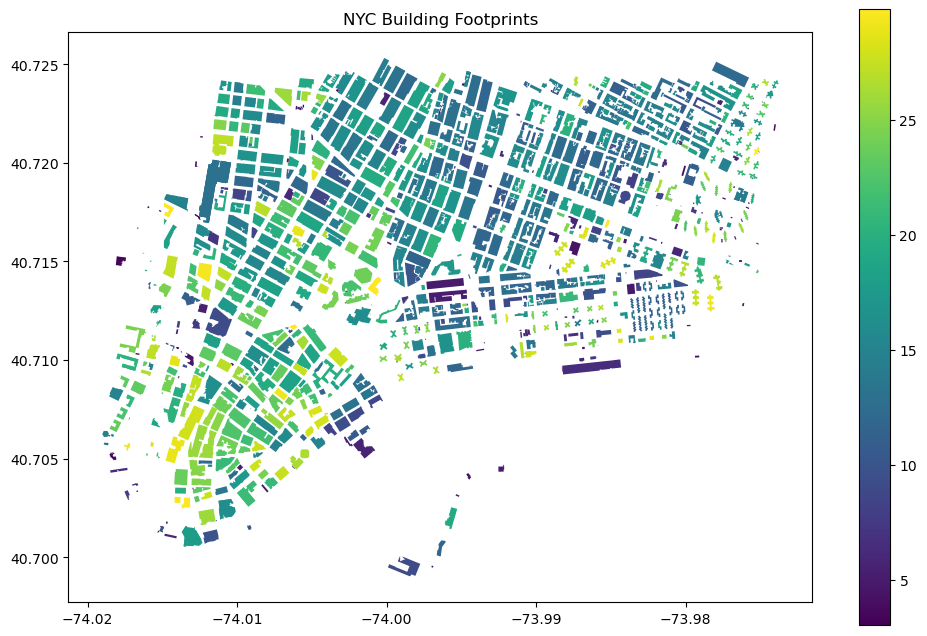

In [65]:
#Plot of building footprints

gdf.plot("height_MS", legend=True, figsize=(12, 8))
plt.title("NYC Building Footprints")
plt.show()

In [66]:
import folium

m = gdf.to_crs(epsg=4326).explore(
    column="height_MS",
    cmap="viridis",
    name="Building Heights",
    tooltip="height_MS",
    legend=True,
    prefer_canvas=True
)

#Add layer control to map - allows for clicking buildings off/on
folium.LayerControl().add_to(m)

#Saving map to html to ensure visibility of final output

m.save("Building_Heights_Map.html")

m

In [67]:
#Compute and output average height of buildings in data set

avg_height = gdf['height_MS'].mean()

print(f"The average building height is: {avg_height:.2f} meters")


The average building height is: 15.45 meters


In [68]:
#Filter buildings from original data set that has a height > mean

tall_bldgs = gdf[gdf['height_MS'] > avg_height]

print(f"There are {tall_bldgs.shape[0]} buildings out of {gdf.shape[0]} that are taller than the average building.")

#Write filtered data to a GeoJSON file

file = "nyc_tall_bldgs.geojson"
gdf.to_file(file, driver="GeoJSON")
print(f"tall_bldgs GDF has been written to {file}")

#Test success by reading GeoJSON into a new GDF

gdf_test = gpd.read_file(file)
gdf_test.head()


There are 524 buildings out of 1206 that are taller than the average building.
tall_bldgs GDF has been written to nyc_tall_bldgs.geojson


,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
0,2,15.05,23.30,19.18,6365.72,36,New York,"POLYGON ((-74.00129 40.71992, -74.00061 40.719..."
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."


## Exercise 10

In [69]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [70]:
#Load world cities dataset from given URL
url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
df = pd.read_csv(url)

#Display first 5 rows
df.head()

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.5833,32.5333,75000
1,2,Fort Portal,UGA,0.6710,30.2750,42670
2,3,Potenza,ITA,40.6420,15.7990,69060
3,4,Campobasso,ITA,41.5630,14.6560,50762
4,5,Aosta,ITA,45.7370,7.3150,34062


In [71]:
#DataFrame representing cities that are between -40° and 60° latitude

filtered_cities = df[df['latitude'].between(-40, 60)]

print (f"There are {filtered_cities.shape[0]} cities between -40° and 60° latitude.")

There are 1132 cities between -40° and 60° latitude.


In [72]:
#Created a GeoDataFrame from filtered_cities by converting the longitude and latitude to geometry

gdf = gpd.GeoDataFrame(filtered_cities, geometry=gpd.points_from_xy(filtered_cities.longitude, filtered_cities.latitude), crs="EPSG:4326")
gdf.head()

,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.5833,32.5333,75000,POINT (32.5333 0.5833)
1,2,Fort Portal,UGA,0.6710,30.2750,42670,POINT (30.275 0.671)
2,3,Potenza,ITA,40.6420,15.7990,69060,POINT (15.799 40.642)
3,4,Campobasso,ITA,41.5630,14.6560,50762,POINT (14.656 41.563)
4,5,Aosta,ITA,45.7370,7.3150,34062,POINT (7.315 45.737)


In [73]:
#Reproject the GeoDataFrame to the Mercator projection EPSG:3857

gdf_3857 = gdf.to_crs(epsg=3857)

gdf_3857.head()


,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.5833,32.5333,75000,POINT (3621590.39 64933.781)
1,2,Fort Portal,UGA,0.6710,30.2750,42670,POINT (3370197.584 74697.086)
2,3,Potenza,ITA,40.6420,15.7990,69060,POINT (1758736.635 4959679.293)
3,4,Campobasso,ITA,41.5630,14.6560,50762,POINT (1631498.457 5095742.084)
4,5,Aosta,ITA,45.7370,7.3150,34062,POINT (814302.075 5738302.989)


In [74]:
#Calculate the distance between each city and Paris.

#Isolate the Paris geometry

paris_geom = gdf_3857.loc[gdf_3857['name'] == "Paris", "geometry"].iloc[0]

#Calculate distances from each city to Paris in meters

gdf_3857['distance_to_paris']= gdf_3857['geometry'].distance(paris_geom)

#Convert distance to km and round to 2 decimal places
gdf_3857['dist_to_paris_km'] = (gdf_3857['distance_to_paris'] / 1000).round(2)

#Print out first 5 rows for visual check
gdf_3857.head()


,id,name,country,latitude,longitude,population,geometry,distance_to_paris,dist_to_paris_km
0,1,Bombo,UGA,0.5833,32.5333,75000,POINT (3621590.39 64933.781),7.041672e+06,7041.67
1,2,Fort Portal,UGA,0.6710,30.2750,42670,POINT (3370197.584 74697.086),6.916454e+06,6916.45
2,3,Potenza,ITA,40.6420,15.7990,69060,POINT (1758736.635 4959679.293),1.979335e+06,1979.34
3,4,Campobasso,ITA,41.5630,14.6560,50762,POINT (1631498.457 5095742.084),1.794231e+06,1794.23
4,5,Aosta,ITA,45.7370,7.3150,34062,POINT (814302.075 5738302.989),7.561058e+05,756.11


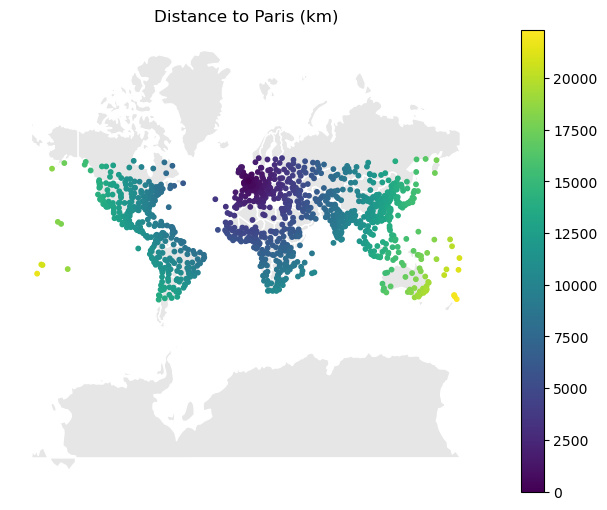

In [75]:
#Load a background world map

url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"

world = gpd.read_file(url)

#Reproject to match project
world_3857 = world.to_crs(epsg=3857)

#Plot the world map - set colors
ax = world_3857.plot(figsize=(10, 6), color='#e6e6e6', edgecolor='white')

#Plot distance data
gdf_3857.plot(ax=ax,
              column='dist_to_paris_km',
              cmap='viridis',
              legend=True,
              markersize=10)


#Configure title and axis
plt.title("Distance to Paris (km)")
ax.set_axis_off()

#Show final plot
plt.show()


In [76]:
#Interactive version of distance to Paris plot

m = gdf_3857.explore(
    column='dist_to_paris_km',
    cmap='viridis',
    tooltip=['name', 'dist_to_paris_km'],
    popup=True,
    tiles="CartoDB positron",
    legend=True,
    marker_kwds=dict(radius=5, fill=True)
)

m.save("dist2paris.html")

m